![Py4Eng](../logo.png)

# Open-Set Metric Learning
## Yoav Ram

In this session we will understand:
- why a classifier's output layer fixes its label set, and what to do when the label set is not fixed
- how **proxy-based** losses replace the pair mining machinery of Siamese networks
- how a `Dense` layer's columns already *are* class proxies, and what changes when you normalize and rescale them — a `CosineHead` written with `keras.ops` only
- how to score a metric space honestly with **Recall@K** and **mAP@R**, and why a baseline with no metric learning at all is mandatory
- that **CLIP** turns a sentence into a class proxy, so classification of species it was never trained on needs no training at all
- above all, **how to tell a negative result from an underpowered experiment** — "this method does nothing here" and "this method does nothing we can measure on a backbone with four points of headroom" are different claims, and only one of them is worth carrying anywhere else

That last one is not a bonus. Three times in this notebook a clean-looking comparison turned out to be
measuring the wrong thing — a shared hyperparameter measuring itself, a sweep reporting its own
boundary, a selection made on the species we report — and each correction changed a conclusion. The
arithmetic of a cosine head takes a cell; learning to distrust a comparison of your own is the part
that transfers.

This is the real version of the Siamese network in
[Keras functional API and Siamese networks](functional_keras.ipynb). There we paired MNIST digits,
trained on the even ones, and asked whether the encoder generalized to the odd ones. Four things change here:

| | `functional_keras.ipynb` | this session |
|---|---|---|
| loss | **pair**-based: two images, same or different | **proxy**-based: one image against every class proxy |
| metric | verification AUC on pairs | ranking: Recall@K and mAP@R |
| data | MNIST, 5 classes held out | CUB-200 birds, **100 species** held out |
| encoder | a small CNN trained from scratch | an ImageNet-pretrained EfficientNetV2S |

The mathematics is the same mathematics. The conclusions are not, and that is the point of doing it twice.

# Closed sets and open sets

Every classifier we have built so far has its label set welded into the shape of its last layer.
`Dense(10, activation='softmax')` can answer *zero* through *nine* and nothing else. Adding an
eleventh digit means a new output layer, new weights and another training run.

An enormous number of real problems are not like that:

- **Face recognition.** The gallery of people is different at every deployment and grows daily.
- **Re-identification.** Track one individual animal, car or person across cameras. The identities
  at test time were never in the training set, by construction.
- **Retrieval.** "Find me more images like this one." There is no label at all.
- **Few-shot learning.** A new class arrives with three examples, not three thousand.

What all of these need is not a classifier but an **embedding**: a function $f$ from images to
$\mathbb{R}^d$ in which distance means something. Once you have it, classification is a nearest-neighbour
lookup against whatever gallery you happen to have today, and the network never has to hear about the
new classes.

The honest test of such an embedding is therefore *not* held-out images of the classes you trained on.
It is held-out **classes**. That is the open-set protocol, and it is what this notebook measures.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import math
import pickle
import tarfile
import time
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

import jax
import keras
from keras import ops
print('Keras:', keras.__version__, 'backend:', keras.backend.backend(), jax.default_backend())

SEED = 23
keras.utils.set_random_seed(SEED)
sns.set(style='white', context='talk')

Keras: 3.15.1 backend: jax cpu


Two helpers. `normalize` projects rows onto the unit sphere — every distance in this notebook is a
cosine distance, so this is the first thing that happens to any embedding. `plot_history` is the
familiar two-panel plot from the other Keras sessions, with the validation curves dropped: as the next
section explains there is no honest validation *set* here, and what replaces it needs a figure of its
own.

In [2]:
def normalize(V):
    """Project rows onto the unit sphere, so that inner product is cosine similarity."""
    V = np.asarray(V, dtype='float32')
    return V / np.maximum(np.linalg.norm(V, axis=1, keepdims=True), 1e-12)


def plot_history(history, title=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    ax = axes[0]
    ax.plot(history['accuracy'], label='Train')
    ax.set(ylabel='Closed-set accuracy', xlabel='Epochs')
    ax.legend()

    ax = axes[1]
    ax.plot(history['loss'], label='Train')
    ax.set(ylabel='Loss', xlabel='Epochs')
    ax.legend()

    if title:
        fig.suptitle(title)
    fig.tight_layout()

# The data: CUB-200-2011, split by class

We reuse [CUB-200-2011](https://www.vision.caltech.edu/datasets/cub_200_2011/) from the
[transfer learning session](transfer.ipynb) — 11,788 photographs of 200 North American bird species —
and the same by-hand download and decoding. What changes is the **split**.

`transfer.ipynb` used the official train/validation split, which divides the *images* and keeps all 200
species on both sides. That is a closed-set split. Here we use the standard metric-learning split
([Song et al. 2016](https://arxiv.org/abs/1511.06452)), which divides the *species*:

- **species 1–100** — 5,864 images — everything we train on;
- **species 101–200** — 5,924 images — evaluation only. The network never sees one of these birds.

**A framing note.** CUB classes are *species*, not individual birds. Re-identification — telling two
individuals of the same species apart — is a harder problem with the same mathematics, and it is where
this material is really used. Everything below transfers; the difficulty does not.

In [3]:
DATA_DIR = Path('../data')
DATASET_DIR = DATA_DIR / 'CUB_200_2011'
ARCHIVE = DATA_DIR / 'CUB_200_2011.tgz'
URL = 'https://data.caltech.edu/records/65de6-vp158/files/CUB_200_2011.tgz?download=1'

DATA_DIR.mkdir(parents=True, exist_ok=True)
if not DATASET_DIR.exists():
    if not ARCHIVE.exists():
        print('Downloading', URL)
        urllib.request.urlretrieve(URL, ARCHIVE)
    print('Extracting archive...')
    with tarfile.open(ARCHIVE, 'r:gz') as archive:
        archive.extractall(path=DATA_DIR, filter='data')
else:
    print('Dataset already available at', DATASET_DIR)

Dataset already available at ../data/CUB_200_2011


In [4]:
images_df = pd.read_csv(DATASET_DIR / 'images.txt', sep=' ', names=['image_id', 'filename'])
labels_df = pd.read_csv(DATASET_DIR / 'image_class_labels.txt', sep=' ', names=['image_id', 'class_id'])
classes_df = pd.read_csv(DATASET_DIR / 'classes.txt', sep=' ', names=['class_id', 'class_name'])

metadata = images_df.merge(labels_df, on='image_id')
labels = metadata.class_id.to_numpy() - 1            # class ids run 1..200 in the file
species = classes_df.class_name.str.split('.').str[1].str.replace('_', ' ').to_numpy()
nclasses = len(species)

print('{:,} images, {} species'.format(len(metadata), nclasses))

11,788 images, 200 species


Decoding the 11,788 JPEGs to a single 224x224 `uint8` array takes about 40 seconds, so it is cached to
disk exactly as in `transfer.ipynb` — and if you have run that session, this cell is instant because the
cache is already there. The array is mapped, not read, so it does not cost 1.8 GB of RAM.

As there, the images stay **`uint8` in 0–255 and are not normalized**. Both backbones in this notebook
do their own input scaling, and both would be silently wrong if handed images in [0, 1].

In [5]:
IMG_SIZE = 224
IMAGES_CACHE = DATA_DIR / 'cub_images_224.npy'

if IMAGES_CACHE.exists():
    images = np.load(IMAGES_CACHE, mmap_mode='r')
    print('Loaded cached array', images.shape, images.dtype)
else:
    paths = [DATASET_DIR / 'images' / filename for filename in metadata.filename]
    images = np.empty((len(paths), IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    t0 = time.time()
    for i, path in enumerate(paths):
        with Image.open(path) as image:
            image = image.convert('RGB').resize((IMG_SIZE, IMG_SIZE))
        images[i] = np.asarray(image, dtype=np.uint8)
    np.save(IMAGES_CACHE, images)
    images = np.load(IMAGES_CACHE, mmap_mode='r')
    print('Decoded {:,} images in {:.0f}s'.format(len(paths), time.time() - t0), images.shape)

Loaded cached array (11788, 224, 224, 3) uint8


Now the class split. `NSEEN = 100` species are for training, the rest are the open set.

We also carve the **last 20 training species** out as a tuning set. Those 20 are held out from *fitting*
whenever we need to choose a hyperparameter, so that the 100 unseen species are touched exactly once, at
the end. This is the single methodological point of [Musgrave et al. 2020](https://arxiv.org/abs/2003.08505):
most of the reported progress in metric learning came from tuning on the test set.

In [6]:
NSEEN = 100
NFIT = 80                                   # species 1..80 fit, 81..100 tune, 101..200 never touched

train_idx = np.flatnonzero(labels < NSEEN)
fit_idx = np.flatnonzero(labels < NFIT)
tune_idx = np.flatnonzero((labels >= NFIT) & (labels < NSEEN))
open_idx = np.flatnonzero(labels >= NSEEN)

y_train, y_fit, y_tune, y_open = (labels[i] for i in (train_idx, fit_idx, tune_idx, open_idx))
Y_train = keras.utils.to_categorical(y_train, NSEEN).astype('float32')
Y_fit = keras.utils.to_categorical(y_fit, NFIT).astype('float32')

for name, idx, first, last, why in (
    ('train', train_idx, 1, NSEEN, 'used to fit the final models'),
    ('fit', fit_idx, 1, NFIT, 'used when a hyperparameter has to be chosen'),
    ('tune', tune_idx, NFIT + 1, NSEEN, 'held-out species, where those choices are made'),
    ('open', open_idx, NSEEN + 1, nclasses, 'never seen, scored once, at the end'),
):
    print('{:>5s}  {:>5,} images, species {:>3d}-{:<3d}  ({})'.format(name, len(idx), first, last, why))
print('\n{:.1f} images per species'.format(len(labels) / nclasses))

train  5,864 images, species   1-100  (used to fit the final models)
  fit  4,672 images, species   1-80   (used when a hyperparameter has to be chosen)
 tune  1,192 images, species  81-100  (held-out species, where those choices are made)
 open  5,924 images, species 101-200  (never seen, scored once, at the end)

58.9 images per species


These are the birds the network will never be trained on. Two images per species, so you can see what
"the same class" has to mean in the embedding — the same species photographed in a different pose,
at a different size, against a different background.

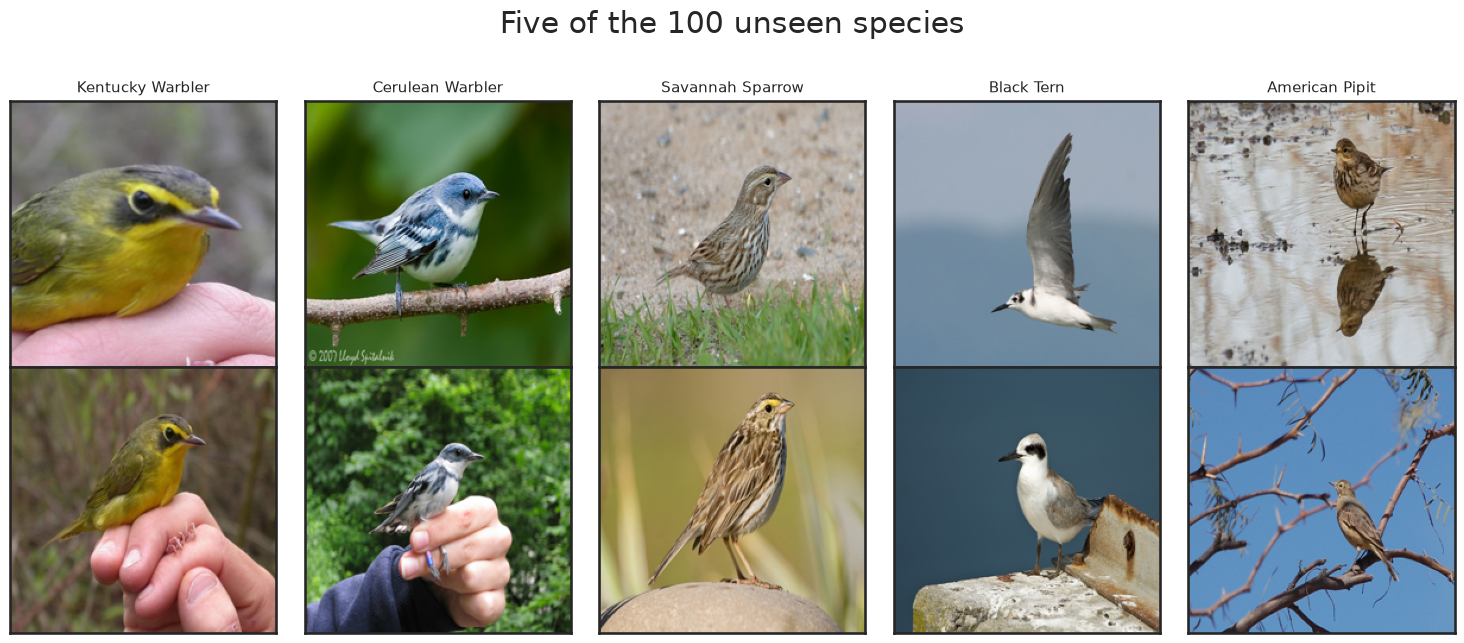

In [7]:
rng = np.random.default_rng(SEED)
picked = rng.choice(np.arange(NSEEN, nclasses), size=5, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(15, 6.5))
for column, class_id in zip(axes.T, picked):
    which = open_idx[y_open == class_id][:2]
    for ax, idx in zip(column, which):
        ax.imshow(images[idx])
        ax.set(xticks=[], yticks=[])
    column[0].set_title(species[class_id], fontsize=11)
fig.suptitle('Five of the 100 unseen species', y=1.0)
fig.tight_layout()

# Pairs, triplets, and why we are leaving them behind

The Siamese network in [`functional_keras.ipynb`](functional_keras.ipynb) learned from **pairs**: two
images and one bit, *same* or *different*. The **triplet loss** ([Schroff et al. 2015](https://arxiv.org/abs/1503.03832))
is its better-known relative — an anchor $a$, a positive $p$ of the same class and a negative $n$ of a
different one, with the loss

$$\mathcal{L} = \max\left(0,\; \|f(a) - f(p)\|^2 - \|f(a) - f(n)\|^2 + \alpha\right),$$

which is zero as soon as the positive is closer than the negative by a margin $\alpha$.

That "as soon as" is the problem. Draw three images at random from CUB and the negative is almost
always already miles away, the loss is already zero, and the gradient is zero with it. Nearly every
triplet you can form teaches the network nothing. The literature's answer is **mining**: search each
batch for *semi-hard* negatives — ones that are close but not closer than the positive — and construct
batches that contain enough same-class images for mining to have anything to chew on (a
*class-balanced sampler*, typically $P$ classes by $K$ images). Mining is fiddly, it interacts with
batch size, and getting it wrong is the usual reason a triplet model underperforms.

**Proxy-based losses delete the whole apparatus.** Instead of comparing samples to other samples, we
give every class one learned vector — a **proxy** — and compare each sample to *all* the proxies at
once. There is nothing to mine, because every sample already sees every class. A batch is just a batch,
and plain shuffling is fine: ArcFace was trained on millions of face images with no special sampler at
all. (Batch composition does start to matter again when the identity distribution is long-tailed, as in
re-identification — but that is a different problem from this one.)

And once you write down "compare each sample to one vector per class, take a softmax", you have
written down something you already know: **a `Dense` layer**. The rest of this notebook is about what
happens when you take that observation seriously.

# The backbone

`EfficientNetV2S`, ImageNet weights, no classifier head, global average pooling — the same 1280-dimensional
feature extractor as in [`transfer.ipynb`](transfer.ipynb), frozen.

**The preprocessing trap, again.** `keras.applications.EfficientNetV2S` takes
`include_preprocessing=True` by default: a `Rescaling` layer *inside* the model expects pixels in
**0–255** and `keras.applications.efficientnet_v2.preprocess_input` is a no-op kept for API
compatibility. Every other family in `keras.applications` is the other way round. Hand this one images
already scaled to [0, 1] and you have divided by 255 twice, silently, and your features will be bad for
no visible reason. We keep the course convention of `uint8` 0–255 and let the model do its own scaling.

Because the backbone is frozen it is a fixed function, so we run it over the dataset once and cache the
11,788 x 1280 matrix. Everything after this point trains on that matrix in seconds, on a CPU. The cache
is shared with `transfer.ipynb`, and `scripts/metric_learning_features.py` will build it (along with the
CLIP arrays we need later) if you would rather not wait here.

In [8]:
EMBEDDINGS_CACHE = DATA_DIR / 'cub_effnetv2s_embeddings.npy'

if EMBEDDINGS_CACHE.exists():
    Z = np.load(EMBEDDINGS_CACHE)
    print('Loaded cached features', Z.shape)
else:
    backbone = keras.applications.EfficientNetV2S(
        weights='imagenet', include_top=False, pooling='avg',
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    backbone.trainable = False
    t0 = time.time()
    Z = backbone.predict(np.asarray(images), batch_size=64, verbose=0).astype('float32')
    np.save(EMBEDDINGS_CACHE, Z)
    print('Embedded {:,} images in {:.0f}s'.format(len(Z), time.time() - t0), Z.shape)

feature_dim = Z.shape[1]

Loaded cached features (11788, 1280)


# Scoring a metric space

There is no accuracy here, because there is no prediction. What we have is a space, and the question is
whether *near* means *same species* in it. The protocol is retrieval: take each of the 5,924 unseen
images in turn as a **query**, rank all the others by cosine similarity, and look at what comes back.

**Recall@K** is the fraction of queries for which at least one of the top $K$ is the same species.
`R@1` is the strictest and the one usually quoted. The query itself must be excluded from its own
ranking — it is its own nearest neighbour, at similarity exactly 1, and forgetting to drop it makes
`R@1` come out at a perfect 100%.

**Recall@K has a flaw**: one lucky neighbour out of $K$ is enough. A space that puts a single correct
bird at rank 1 and rubbish at ranks 2–10 scores the same `R@1` as a space that gets all ten right.
**mAP@R** ([Musgrave et al. 2020](https://arxiv.org/abs/2003.08505)) fixes that. For a query with $R$
other images of its species in the gallery, look at exactly the top $R$ results and average the
precision at each correct hit:

$$\text{AP@R} = \frac{1}{R}\sum_{i=1}^{R} \mathbb{1}[\text{hit at } i] \cdot P(i),
\qquad P(i) = \frac{\text{hits in the top } i}{i}.$$

It rewards getting the whole neighbourhood right and it has no free parameter $K$. Its numbers look
brutal next to Recall@K — that is because it is measuring something much harder, not because the model
got worse. We report both.

In [9]:
def retrieval_scores(embeddings, y, ks=(1, 5, 10)):
    """Recall@K and mAP@R for a set of embeddings, each image used once as a query."""
    E = normalize(embeddings)
    similarity = E @ E.T
    np.fill_diagonal(similarity, -np.inf)               # a query is not its own neighbour
    ranking = np.argsort(-similarity, axis=1)
    hit = y[ranking] == y[:, None]

    scores = {'R@{}'.format(k): hit[:, :k].any(axis=1).mean() for k in ks}

    # mAP@R: for each query, R is the number of other images of its own species
    R = np.bincount(y)[y] - 1
    depth = int(R.max())
    relevant = hit[:, :depth]
    precision = np.cumsum(relevant, axis=1) / np.arange(1, depth + 1)
    within_R = np.arange(depth)[None, :] < R[:, None]
    scores['mAP@R'] = ((precision * relevant * within_R).sum(axis=1) / np.maximum(R, 1)).mean()
    return scores


def report(name, scores):
    print('{:38s}'.format(name) + '  '.join('{} {:6.2%}'.format(k, v) for k, v in scores.items()))

# Baseline 0: no metric learning at all

Before training anything, score the frozen ImageNet features themselves. This baseline is not optional.
It is the number every method in this notebook has to beat to have earned its complexity, and on CUB it
is a strong one — ImageNet contains 59 bird classes, so the backbone already knows a good deal about
feathers.

In [10]:
frozen_scores = retrieval_scores(Z[open_idx], y_open)
report('Frozen ImageNet features', frozen_scores)
print('\nchance R@1 would be about {:.2%}'.format(1 / 100))

Frozen ImageNet features              R@1 48.92%  R@5 75.83%  R@10 84.99%  mAP@R 12.24%

chance R@1 would be about 1.00%


What does that actually look like? Here are four queries from the unseen species with their five nearest
neighbours in the frozen feature space. A green frame means the neighbour is the same species as the
query, red means it is not.

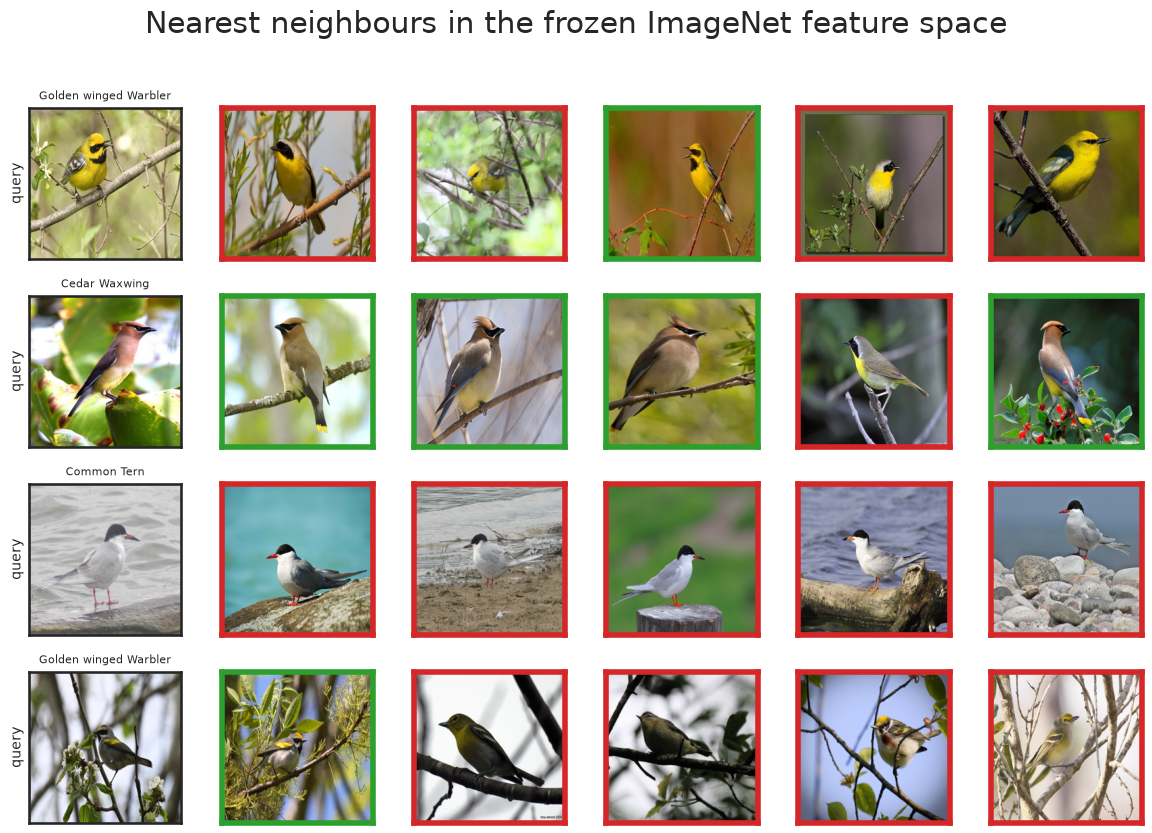

In [11]:
def plot_neighbours(embeddings, y, idx, queries, k=5, title=None):
    E = normalize(embeddings)
    similarity = E @ E.T
    np.fill_diagonal(similarity, -np.inf)
    ranking = np.argsort(-similarity, axis=1)[:, :k]

    fig, axes = plt.subplots(len(queries), k + 1, figsize=(2.0 * (k + 1), 2.1 * len(queries)))
    for row, q in zip(axes, queries):
        row[0].imshow(images[idx[q]])
        row[0].set(xticks=[], yticks=[])
        row[0].set_ylabel('query', fontsize=10)
        row[0].set_title(species[y[q]], fontsize=8)
        for ax, n in zip(row[1:], ranking[q]):
            ax.imshow(images[idx[n]])
            ax.set(xticks=[], yticks=[])
            correct = y[n] == y[q]
            for spine in ax.spines.values():
                spine.set(edgecolor='tab:green' if correct else 'tab:red', linewidth=4)
    if title:
        fig.suptitle(title, y=1.0)
    fig.tight_layout()


plot_neighbours(Z[open_idx], y_open, open_idx, rng.choice(len(open_idx), size=4, replace=False),
                title='Nearest neighbours in the frozen ImageNet feature space')

# Baseline 1: plain softmax cross-entropy

The first thing to try is the thing we already know how to do: train an ordinary 100-way classifier on
the training species and then **throw the classifier away**, keeping the penultimate layer as the
embedding. No metric learning, no margin, no pairs.

This baseline is frequently left out of metric-learning papers and it is frequently competitive. It is
also the fair point of comparison for ArcFace, so the two share a trunk exactly:

```
1280-d frozen features -> Dense(512, no bias) -> BatchNormalization -> embedding
```

and differ only in what is bolted on top. The `Dense`-then-`BatchNormalization` pair is the **BNNeck**
of [Luo et al. 2019](https://arxiv.org/abs/1903.07071), the standard re-identification baseline — down to
the classifier having no bias, and the *post*-BN feature being the one used for retrieval, and it is not cosmetic: dropping it costs this baseline
about **seven points** of `R@1`, which is several times what any loss function in this notebook is
worth. It is worth knowing that before attributing anything to a choice of loss.

In [12]:
EMBEDDING_DIM = 512


def build_trunk(seed, input_dim):
    """Frozen features -> 512-d embedding. Shared by every model in this notebook."""
    keras.utils.set_random_seed(seed)
    features = keras.Input(shape=(input_dim,), name='features')
    embedding = keras.layers.Dense(EMBEDDING_DIM, use_bias=False, name='embedding')(features)
    embedding = keras.layers.BatchNormalization(name='embedding_bn')(embedding)
    return features, embedding


def build_softmax(seed, nclasses, input_dim, learning_rate):
    features, embedding = build_trunk(seed, input_dim)
    yhat = keras.layers.Dense(nclasses, activation='softmax', name='species')(embedding)
    model = keras.Model(features, yhat, name='softmax')
    model.compile(
        loss='categorical_crossentropy',
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=['accuracy'],
    )
    return model


def encoder_of(model):
    """At inference the head is discarded and only the embedding is kept."""
    return keras.Model(model.input, model.get_layer('embedding_bn').output)


build_softmax(SEED, NSEEN, feature_dim, 3e-4).summary()

Model: "softmax"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Dense)               │ (None, 512)            │       655,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_bn                    │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ species (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 708,708 (2.70 MB)

 Trainable params: 707,684 (2.70 MB)

 Non-trainable params: 1,024 (4.00 KB)

## How long to train, and how we are allowed to decide

There is no validation *set* in this notebook, because there is no honest one: held-out images of the
training species would measure closed-set accuracy, which is not what we care about, and the unseen
species are the test set and may not be used to make decisions.

What we use instead is the 20 held-out **species** from the training half. A callback re-embeds them
after every epoch and scores retrieval, so we can watch open-set quality directly while the model
trains — on classes the model is not being fitted to, and which are not the 100 we report on.

In [13]:
class RetrievalMonitor(keras.callbacks.Callback):
    """Score open-set retrieval on held-out classes after every epoch.

    The scores are written into `logs` under a `tune_` prefix as well as kept here, so
    that stock Keras callbacks -- `EarlyStopping` below -- can watch them like any
    built-in metric.
    """

    def __init__(self, features, y, every=1):
        super().__init__()
        self.features, self.y, self.every = features, y, every
        self.history = {}
        self.encoder = None

    def on_train_begin(self, logs=None):
        # build the encoder view once; rebuilding it every epoch dominates the cost
        self.encoder = encoder_of(self.model)

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every:
            return
        embeddings = self.encoder.predict(self.features, batch_size=512, verbose=0)
        for key, value in retrieval_scores(embeddings, self.y).items():
            self.history.setdefault(key, []).append(value)
            if logs is not None:
                logs['tune_' + key] = value
        self.history.setdefault('epoch', []).append(epoch + 1)

Fit the softmax baseline on the 80 fitting species for a deliberately long 80 epochs, and watch both
numbers at once.

In [14]:
LEARNING_RATE = 3e-4
BATCH_SIZE = 128
LONG_RUN = 80

monitor = RetrievalMonitor(Z[tune_idx], y_tune, every=2)
long_softmax = build_softmax(SEED, NFIT, feature_dim, LEARNING_RATE)
t0 = time.time()
long_softmax_history = long_softmax.fit(
    x=Z[fit_idx], y=Y_fit, batch_size=BATCH_SIZE, epochs=LONG_RUN,
    callbacks=[monitor], verbose=0,
).history
long_softmax_retrieval = monitor.history
print('Trained {} epochs in {:.0f}s'.format(LONG_RUN, time.time() - t0))

Trained 80 epochs in 13s


mAP@R on the held-out species peaks at epoch 22


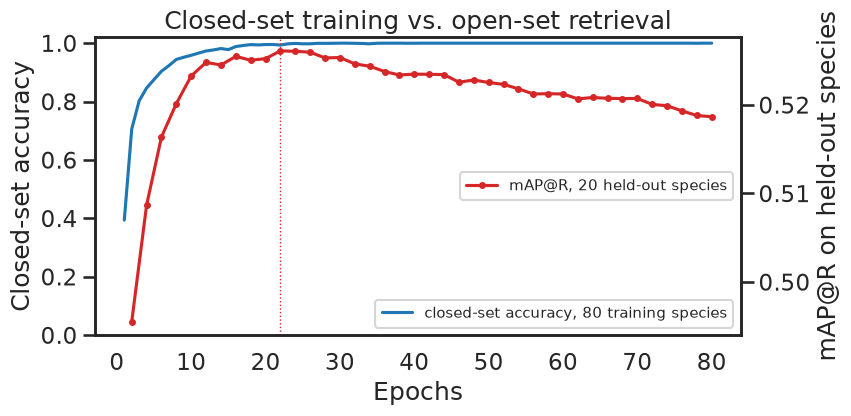

In [15]:
def plot_overfitting(closed, retrieval, title=None):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(np.arange(1, len(closed['accuracy']) + 1), closed['accuracy'],
            color='tab:blue', label='closed-set accuracy, 80 training species')
    ax.set(xlabel='Epochs', ylabel='Closed-set accuracy', ylim=(0, 1.02))
    ax.legend(loc='lower right', fontsize=11)

    twin = ax.twinx()
    twin.plot(retrieval['epoch'], retrieval['mAP@R'], color='tab:red', marker='o', ms=4,
              label='mAP@R, 20 held-out species')
    best = int(np.argmax(retrieval['mAP@R']))
    twin.axvline(retrieval['epoch'][best], color='tab:red', ls=':', lw=1)
    twin.set(ylabel='mAP@R on held-out species')
    twin.legend(loc='center right', fontsize=11)
    twin.grid(False)
    if title:
        ax.set_title(title)
    fig.tight_layout()
    return retrieval['epoch'][best]


best_epoch = plot_overfitting(long_softmax_history, long_softmax_retrieval,
                              title='Closed-set training vs. open-set retrieval')
print('mAP@R on the held-out species peaks at epoch', best_epoch)

The blue curve is the model getting better at the task it was given. The red curve is the model getting
worse at the task we actually want. They diverge early: the embedding is most useful for *unseen*
species long before the classifier has finished fitting the *seen* ones, and training to convergence
actively destroys the property we came for.

This is not ordinary overfitting — the closed-set curve is *training* accuracy, and it goes where
training accuracy always goes. It is the classifier specializing its features to the exact 80-way
decision it was asked for, discarding everything about a bird that does not help separate those 80
species.

So **when to stop is a hyperparameter**, and it has to be chosen the same way as any other: on the
held-out species. Because the monitor writes its scores into `logs`, the stock `EarlyStopping` callback
can do it for us — watching `tune_mAP@R` rather than a validation loss, maximizing rather than
minimizing, and `restore_best_weights=True` to roll the weights back to the peak rather than leaving
them wherever training happened to stop.

We watch mAP@R rather than `R@1` on [Musgrave et al.](https://arxiv.org/abs/2003.08505)'s own grounds:
they measure the lag-one autocorrelation of validation accuracy during training at 0.73 for `R@1` against
0.81 for mAP@R, and conclude that mAP@R "is less noisy, making it easier to select the best performing
model checkpoints". Choosing a stopping epoch is exactly that job.

`patience` only decides how many wasted epochs we pay to confirm the peak; it does not change which
epoch is chosen. Ten is comfortable here.

In [16]:
MAX_EPOCHS = 32
PATIENCE = 10


def fit_with_early_stopping(model, x, y, monitor_features, monitor_y):
    """Train until open-set retrieval on the held-out species stops improving."""
    monitor = RetrievalMonitor(monitor_features, monitor_y)
    stopping = keras.callbacks.EarlyStopping(
        monitor='tune_mAP@R', mode='max', patience=PATIENCE, restore_best_weights=True,
    )
    history = model.fit(
        x=x, y=y, batch_size=BATCH_SIZE, epochs=MAX_EPOCHS,
        callbacks=[monitor, stopping], verbose=0,
    ).history
    best = int(np.argmax(monitor.history['mAP@R']))
    return history, monitor, monitor.history['epoch'][best]

There is one wrinkle. The final models are fitted on all 100 training species, but the species we are
allowed to watch are 20 *of* those 100 — so we cannot watch them and fit them at the same time. We do
what the sweep will do: find the epoch on species 1–80 with species 81–100 held out, then refit on all
100 for exactly that long.

softmax peaks on the held-out species at epoch 25


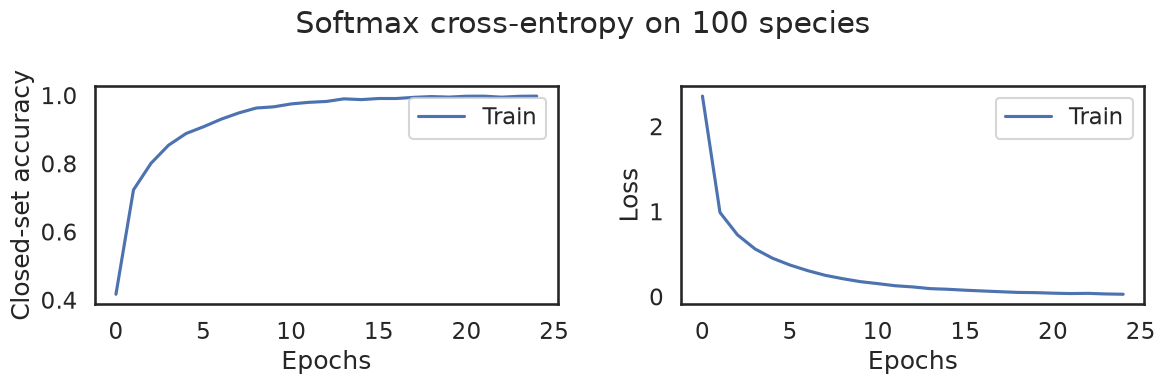

In [17]:
softmax_search = build_softmax(SEED, NFIT, feature_dim, LEARNING_RATE)
_, _, softmax_epochs = fit_with_early_stopping(
    softmax_search, Z[fit_idx], Y_fit, Z[tune_idx], y_tune)
print('softmax peaks on the held-out species at epoch', softmax_epochs)

softmax_model = build_softmax(SEED, NSEEN, feature_dim, LEARNING_RATE)
softmax_history = softmax_model.fit(
    x=Z[train_idx], y=Y_train, batch_size=BATCH_SIZE, epochs=softmax_epochs, verbose=0,
).history
plot_history(softmax_history, title='Softmax cross-entropy on 100 species')

In [18]:
softmax_embeddings = encoder_of(softmax_model).predict(Z[open_idx], batch_size=512, verbose=0)
softmax_scores = retrieval_scores(softmax_embeddings, y_open)
report('Softmax cross-entropy', softmax_scores)
report('Frozen ImageNet features', frozen_scores)

Softmax cross-entropy                 R@1 52.28%  R@5 79.32%  R@10 87.56%  mAP@R 15.61%
Frozen ImageNet features              R@1 48.92%  R@5 75.83%  R@10 84.99%  mAP@R 12.24%


Training a classifier and discarding it improves the embedding, on every metric. Keep that number: it is
the one the rest of the notebook has to beat.

# Proxies you can see: the cosine head

Look again at what the last layer of that classifier does. A `Dense` layer with weights
$W \in \mathbb{R}^{d \times C}$ computes $W_c^\top x$ for each class $c$ — an inner product between the
embedding $x$ and one column per class. Those columns *are* class representatives living in the same
space as the embeddings. They are the **proxies** from the section above, and softmax cross-entropy was
training them all along without ever saying so.

Once you see them that way, two things about the `Dense` layer look wrong for our purposes.

**1. Nothing constrains the lengths.** The logit $W_c^\top x = \|W_c\|\,\|x\|\cos\theta_c$ mixes three
quantities, and only one of them — the angle $\theta_c$ — is what we use at test time, since retrieval
is by cosine similarity. A `Dense` layer can reduce its training loss by making $\|x\|$ large, which
does nothing for any angle. That is capacity spent on something we then throw away.

So L2-normalize both sides and keep only the angle: $\hat{W}_c^\top \hat{x} = \cos\theta_c$. Now the
layer optimizes exactly the quantity the evaluation uses.

**2. Cosines are too small to be confident.** They live in $[-1, 1]$, and a softmax over logits that
small cannot concentrate — the cross-entropy has a floor it cannot get under, whatever the model does.
So multiply by a **scale** $s$ to restore the dynamic range. $s$ looks like a technicality. It is not:
it turns out to be the one hyperparameter here that matters.

That is the whole layer. It is a `Dense` layer with the biases removed and both sides normalized.

In [19]:
@keras.saving.register_keras_serializable(package='metric_learning')
class CosineHead(keras.layers.Layer):
    """Cosine similarity between an embedding and one learned proxy per class, scaled by `s`.

    No bias: a bias would shift a logit without changing any angle. The output is `s * cos(theta)`,
    which is an ordinary logit vector -- so this layer needs no custom loss to go with it, just
    categorical cross-entropy told that its inputs are logits.
    """

    def __init__(self, num_classes, scale=16.0, **kwargs):
        super().__init__(**kwargs)
        self.num_classes = num_classes
        self.scale = scale

    def build(self, input_shape):
        self.proxies = self.add_weight(
            shape=(input_shape[-1], self.num_classes),
            initializer='glorot_uniform',
            name='proxies',
        )

    def call(self, embeddings):
        embeddings = embeddings / (ops.norm(embeddings, axis=-1, keepdims=True) + 1e-12)
        proxies = self.proxies / (ops.norm(self.proxies, axis=0, keepdims=True) + 1e-12)
        return self.scale * ops.matmul(embeddings, proxies)

    def get_config(self):
        return {**super().get_config(), 'num_classes': self.num_classes, 'scale': self.scale}

**And that is all the custom code this notebook needs.** No custom loss, no second input for the
labels, no training-time/inference-time asymmetry. The head emits logits; `CategoricalCrossentropy`
consumes logits; at test time we drop the head and keep the embedding.

It is worth knowing what we have *not* built, because it is the famous part. **ArcFace**
([Deng et al. 2019](https://arxiv.org/abs/1801.07698)) adds one more idea on top of exactly this layer:
an **angular margin**. Instead of asking that $\theta_y$ be smaller than every other $\theta_c$, it asks
that it be smaller *by $m$ radians*, substituting $\cos(\theta_y + m)$ for $\cos\theta_y$ when computing
the loss — which pushes every sample well inside its own class's angular cone rather than just over the
boundary. That is the part the method is named after, it needs a custom loss (the margin applies only to
the true class, so it has to see the labels), and it is where the sharp implementation traps live.

We stop here for a reason that took this notebook three drafts to establish: **on this problem the
margin is worth nothing we can measure.** The normalization and the scale do all the work. Exercise 3
walks you through adding the margin and measuring it yourself, and
[`sessions/reid.ipynb`](reid.ipynb) picks it up properly, in the regime it was designed for — hundreds
of individual animals with one to ten photographs each, where the proxies of rare classes are badly
undertrained and a margin has something to fix.

## Choosing the scale

The cosine head has exactly one hyperparameter, and the literature treats it as plumbing. ArcFace uses
$s = 64$; other papers use 30. Those numbers come from face recognition — millions of images, tens of
thousands of identities, a backbone free to move. We have 5,864 images, 100 species and a **frozen**
backbone, so there is no reason for them to carry over, and we should find out rather than assume.

Two rules for the sweep, both of which this notebook learned the hard way.

**The grid has to bracket the answer.** An earlier draft swept $s \in \{16, 30, 64\}$, reported "best
$s = 16$", and was wrong — 16 was the smallest value in the grid, so that is not an optimum, it is a
wall. A search that selects a value at the edge of its range has not finished. We go down to $s = 2$,
and you should check that the winner ends up with neighbours on both sides.

**Every configuration gets its own stopping point.** The previous section showed open-set quality
peaking and then decaying; different scales peak at different epochs, so a budget chosen once, on one
configuration, would quietly penalize the others. Each run trains for a fixed long stretch with the
monitor attached and we keep the whole curve, so each can be scored at a shared budget *and* at its own
peak. Which of the two we use turns out to matter more than $s$ does.

In [20]:
def build_cosine(seed, nclasses, input_dim, learning_rate, scale):
    features, embedding = build_trunk(seed, input_dim)
    logits = CosineHead(nclasses, scale=scale, name='cosine')(embedding)
    model = keras.Model(features, logits, name='cosine')
    model.compile(
        loss=keras.losses.CategoricalCrossentropy(from_logits=True),
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        metrics=['accuracy'],
    )
    return model


SCALES = (2.0, 4.0, 8.0, 16.0, 32.0, 64.0)
SWEEP_EPOCHS = 25
SHARED_BUDGET = 20              # what a single fixed budget would have been


def sweep_scale(features):
    """Fit every scale on species 1-80, scoring species 81-100 every epoch."""
    curves = {}
    for scale in SCALES:
        model = build_cosine(SEED, NFIT, features.shape[1], LEARNING_RATE, scale)
        monitor = RetrievalMonitor(features[tune_idx], y_tune)
        model.fit(x=features[fit_idx], y=Y_fit, batch_size=BATCH_SIZE,
                  epochs=SWEEP_EPOCHS, callbacks=[monitor], verbose=0)
        curves[scale] = monitor.history
    return curves


t0 = time.time()
curves = sweep_scale(Z)
print('{} scales x {} epochs in {:.0f}s'.format(len(curves), SWEEP_EPOCHS, time.time() - t0))

6 scales x 25 epochs in 28s


In [21]:
def summarize_sweep(curves):
    return pd.DataFrame([
        {
            's': scale,
            'at epoch {}'.format(SHARED_BUDGET): curve['mAP@R'][SHARED_BUDGET - 1],
            'best': max(curve['mAP@R']),
            'best epoch': curve['epoch'][int(np.argmax(curve['mAP@R']))],
        }
        for scale, curve in curves.items()
    ]).set_index('s')


sweep = summarize_sweep(curves)

# the two references the sweep has to be read against, on the same held-out species
tune_frozen = retrieval_scores(Z[tune_idx], y_tune)
tune_softmax_model = build_softmax(SEED, NFIT, feature_dim, LEARNING_RATE)
tune_softmax_model.fit(x=Z[fit_idx], y=Y_fit, batch_size=BATCH_SIZE, epochs=softmax_epochs, verbose=0)
tune_softmax = retrieval_scores(
    encoder_of(tune_softmax_model).predict(Z[tune_idx], batch_size=512, verbose=0), y_tune)

print('mAP@R on the 20 held-out species')
print(sweep.to_string(formatters={c: '{:.2%}'.format for c in sweep.columns if c != 'best epoch'}))
print()
report('softmax, same 80 species', tune_softmax)
report('frozen features', tune_frozen)

mAP@R on the 20 held-out species
     at epoch 20   best  best epoch
s                                  
2.0       48.83% 52.51%           7
4.0       51.91% 53.63%           9
8.0       53.87% 54.73%          11
16.0      53.63% 54.02%          15
32.0      52.18% 52.33%          11
64.0      51.38% 51.41%          22

softmax, same 80 species              R@1 87.25%  R@5 95.89%  R@10 97.48%  mAP@R 52.62%
frozen features                       R@1 86.41%  R@5 94.71%  R@10 96.81%  mAP@R 49.41%


**Before reading any of these numbers**: mAP@R here is on **20** species and a gallery of 1,192 images.
The final comparison later is on **100** species and 5,924 images, and the same metric will land around
16% instead of 54%. That is not the model falling apart — mAP@R gets harder as the gallery grows and the
classes multiply, because a query has more ways to be wrong and more relevant items to rank correctly.
Compare numbers within a table, never across those two.

best scale on the held-out species: s = 8


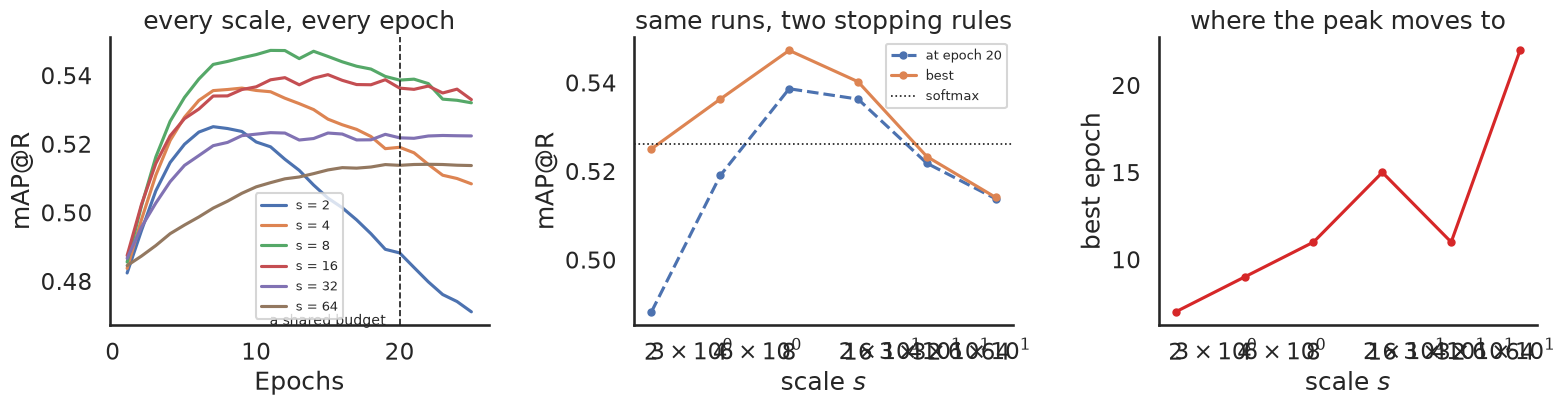

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

ax = axes[0]
for scale in SCALES:
    ax.plot(curves[scale]['epoch'], curves[scale]['mAP@R'], label='s = {:.0f}'.format(scale))
ax.axvline(SHARED_BUDGET, color='k', ls='--', lw=1.2)
ax.text(SHARED_BUDGET - 1, ax.get_ylim()[0], ' a shared budget', fontsize=10, ha='right')
ax.set(xlabel='Epochs', ylabel='mAP@R', title='every scale, every epoch')
ax.legend(fontsize=9)

ax = axes[1]
for column, style in (('at epoch {}'.format(SHARED_BUDGET), 'o--'), ('best', 'o-')):
    ax.plot(SCALES, sweep[column], style, ms=5, label=column)
ax.axhline(tune_softmax['mAP@R'], color='k', ls=':', lw=1.2, label='softmax')
ax.set(xscale='log', xlabel='scale $s$', ylabel='mAP@R', title='same runs, two stopping rules')
ax.set_xticks(SCALES)
ax.set_xticklabels(['{:.0f}'.format(s) for s in SCALES])
ax.legend(fontsize=9)

ax = axes[2]
ax.plot(SCALES, sweep['best epoch'], 'o-', ms=5, color='tab:red')
ax.set(xscale='log', xlabel='scale $s$', ylabel='best epoch', title='where the peak moves to')
ax.set_xticks(SCALES)
ax.set_xticklabels(['{:.0f}'.format(s) for s in SCALES])

sns.despine()
fig.tight_layout()

BEST_SCALE = sweep['best'].idxmax()
print('best scale on the held-out species: s = {:.0f}'.format(BEST_SCALE))

**The scale is worth about two points of mAP@R, and its optimum is interior.** The winner has worse
neighbours on both sides, which is what makes it an optimum rather than an artifact of where we stopped
looking. Had we kept the original $\{16, 30, 64\}$ grid we would have reported the wrong value and had
no way to know.

**It is not plumbing.** Two points is more than the difference between the cosine head and plain softmax
in the first place. The parameter introduced to stop the cross-entropy bottoming out turns out to be the
main thing there is to tune here — and the paper values, 30 and 64, are both on the bad side of the
curve for this problem.

**The peak moves with the scale.** That is the right-hand panel, and it is why every configuration got
its own budget: the best epoch roughly triples across the grid. A budget picked once, on one scale,
would have been measuring the budget rather than the scale. It is worth being precise about how easy
that mistake is to make — the dashed line in the middle panel is not a careless choice, it is exactly
the number the previous section arrived at, honestly, on held-out classes. It was simply arrived at
*once*, for a different model.

From here on the scale comes from this sweep and every model gets its own stopping point.

Softmax cross-entropy          25 epochs


Cosine head (s=8)              11 epochs


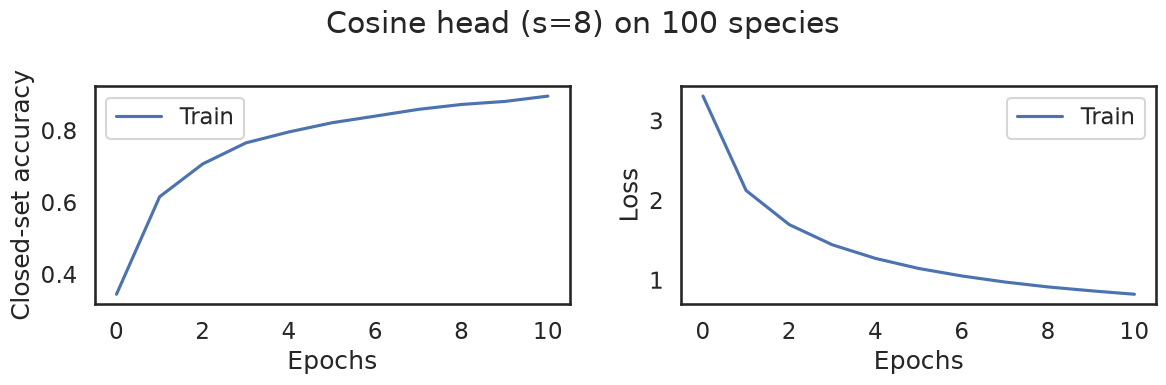

In [23]:
def fit_final(builder, name, features=None, seed=SEED, quiet=False):
    """Choose the budget on species 1-80/81-100, then refit on all 100."""
    features = Z if features is None else features
    search = builder(seed, NFIT, features.shape[1], LEARNING_RATE)
    _, _, epochs = fit_with_early_stopping(
        search, features[fit_idx], Y_fit, features[tune_idx], y_tune)
    model = builder(seed, NSEEN, features.shape[1], LEARNING_RATE)
    history = model.fit(x=features[train_idx], y=Y_train, batch_size=BATCH_SIZE,
                        epochs=epochs, verbose=0).history
    if not quiet:
        print('{:30s} {:2d} epochs'.format(name, epochs))
    return model, history, epochs


cosine_name = 'Cosine head (s={:.0f})'.format(BEST_SCALE)
cosine_builder = lambda seed, n, d, lr: build_cosine(seed, n, d, lr, BEST_SCALE)

print('{:30s} {:2d} epochs'.format('Softmax cross-entropy', softmax_epochs))
cosine_model, cosine_history, cosine_epochs = fit_final(cosine_builder, cosine_name)
plot_history(cosine_history, title=cosine_name + ' on 100 species')

In [24]:
cosine_scores = retrieval_scores(
    encoder_of(cosine_model).predict(Z[open_idx], batch_size=512, verbose=0), y_open)

report(cosine_name, cosine_scores)
report('Softmax cross-entropy', softmax_scores)
report('Frozen ImageNet features', frozen_scores)

Cosine head (s=8)                     R@1 52.73%  R@5 78.65%  R@10 86.90%  mAP@R 16.36%
Softmax cross-entropy                 R@1 52.28%  R@5 79.32%  R@10 87.56%  mAP@R 15.61%
Frozen ImageNet features              R@1 48.92%  R@5 75.83%  R@10 84.99%  mAP@R 12.24%


Save both models. Only the trunk will ever be used again — `encoder_of` drops the head, and with it the
proxies, which are meaningless for species the model never trained on.

In [25]:
softmax_model.save('../data/cub_metric_softmax.keras')
cosine_model.save('../data/cub_metric_cosine.keras')
for name, history in (('softmax', softmax_history), ('cosine', cosine_history)):
    with open('../data/cub_metric_{}_history.p'.format(name), 'wb') as f:
        pickle.dump(history, f)

In [26]:
softmax_model = keras.models.load_model('../data/cub_metric_softmax.keras')
cosine_model = keras.models.load_model('../data/cub_metric_cosine.keras')
for name in ('softmax', 'cosine'):
    with open('../data/cub_metric_{}_history.p'.format(name), 'rb') as f:
        pickle.load(f)

## Run-to-run variance

A one-point difference means nothing unless we know how much the number moves when only the seed
changes. Both models are cheap, so we retrain each of them twice more — epoch budget and all, so that
the budget's own variability is inside the range we report — and give the spread.

In [27]:
SEEDS = (SEED, SEED + 1, SEED + 2)
builders = {
    'Softmax cross-entropy': lambda seed, n, d, lr: build_softmax(seed, n, d, lr),
    cosine_name: cosine_builder,
}

runs, budgets = {}, {}
for name, builder in builders.items():
    runs[name], budgets[name] = [], []
    for seed in SEEDS:
        model, _, epochs = fit_final(builder, name, seed=seed, quiet=True)
        runs[name].append(retrieval_scores(
            encoder_of(model).predict(Z[open_idx], batch_size=512, verbose=0), y_open))
        budgets[name].append(epochs)

for name, scores in runs.items():
    print('{:30s} epochs {:<12s} '.format(name, str(budgets[name])) + '  '.join(
        '{} {:.2%}-{:.2%}'.format(k, min(s[k] for s in scores), max(s[k] for s in scores))
        for k in scores[0]))

Softmax cross-entropy          epochs [25, 22, 22] R@1 52.14%-52.38%  R@5 78.49%-79.32%  R@10 86.88%-87.56%  mAP@R 15.50%-15.61%
Cosine head (s=8)              epochs [11, 11, 11] R@1 51.64%-52.73%  R@5 78.36%-78.65%  R@10 86.60%-86.90%  mAP@R 16.19%-16.36%


# CLIP: proxies you write down instead of learning

Everything above learned its proxies from labelled photographs of birds. One column of `ArcFaceHead`'s
weight matrix per species, fitted by gradient descent, and a hundred species is a hundred columns we had
to have data for.

[CLIP](https://arxiv.org/abs/2103.00020) (Radford et al. 2021) was trained on 400 million
(image, caption) pairs from the web with a contrastive objective: push each image's embedding towards
its own caption's embedding and away from the other captions in the batch. What comes out is two
encoders — one for images, one for text — whose outputs live in **the same 512-dimensional space**.

Which means the text encoder is a **proxy generator**. Feed it `"a photo of a Painted Bunting"` and it
returns a vector in the same space as the image embeddings, playing exactly the role of a column of
`ArcFaceHead.proxies`. The difference is that it was not fitted to any bird photograph: it was
*written down*, in English, at test time.

So zero-shot classification is nearest-proxy retrieval with the proxy matrix built from sentences:

$$\hat{y} = \arg\max_c \; \hat{f}_\text{image}(x)^\top \hat{f}_\text{text}(\text{prompt}_c).$$

Same operation as `ArcFaceHead.call`. Different source of proxies. No training at all.

## Getting CLIP, without TensorFlow

We use the CLIP presets in [KerasHub](https://keras.io/keras_hub/), so everything stays in Keras 3 on
JAX. Two things about that are worth knowing before you run the next cell.

**`keras-hub` declares `tensorflow-text` as a dependency**, which drags in TensorFlow. This course does
not install TensorFlow, and a TensorFlow that shares a GPU with JAX is a reliable source of
out-of-memory errors. Install it without its dependency tree — the three packages it actually needs are already in the
course's `requirements.txt`:

```bash
python -m pip install --no-deps keras-hub
```

**The CLIP tokenizer then does not work**, and the error is nowhere near the cause. `keras-hub` 0.32
builds byte-pair tokenizers by calling a TensorFlow implementation first, catching the resulting
`ImportError` and falling back to a pure-Python one — but the TensorFlow call is what assigns
`self.vocabulary`, and the fallback reads that attribute instead of its own argument. Without
TensorFlow you get `AttributeError: 'NoneType' object has no attribute 'copy'` from deep inside
`set_vocabulary_and_merges`. Assigning the two attributes first is enough to fix it.

There is no ready-made zero-shot task class, so we compose the pieces ourselves — which suits us,
because the composition is the thing being taught.

In [28]:
from keras_hub.layers import CLIPImageConverter
from keras_hub.models import CLIPBackbone, CLIPTokenizer

CLIP_PRESET = 'clip_vit_base_patch16'

# keras-hub 0.32 only assigns `vocabulary` and `merges` in its TensorFlow code path,
# which we do not install; the pure-Python path then reads them back as None.
_set_vocabulary_and_merges = CLIPTokenizer._set_vocabulary_and_merges_tokenizers

def _set_vocabulary_and_merges_without_tensorflow(self, vocabulary, merges):
    self.vocabulary = vocabulary.copy()
    self.merges = list(merges)
    return _set_vocabulary_and_merges(self, vocabulary, merges)

CLIPTokenizer._set_vocabulary_and_merges_tokenizers = _set_vocabulary_and_merges_without_tensorflow

In [29]:
clip = CLIPBackbone.from_preset(CLIP_PRESET)
clip_tokenizer = CLIPTokenizer.from_preset(CLIP_PRESET)
clip_converter = CLIPImageConverter.from_preset(CLIP_PRESET)

print('{:,} parameters, projecting into {} dimensions'.format(
    clip.count_params(), clip.vision_projection.units))
print('vocabulary of {:,} byte-pair tokens'.format(clip_tokenizer.vocabulary_size()))

149,620,934 parameters, projecting into 512 dimensions
vocabulary of 49,408 byte-pair tokens


The text encoder wants a fixed-length row of token ids bracketed by the start and end tokens. KerasHub
has a `CLIPPreprocessor` that would do this, but its default `to_lower=True` calls into TensorFlow — and
it is unnecessary, because the tokenizer already lowercases in its own normalizer. Seventy-seven tokens
is CLIP's context length; everything shorter is padded with zeros, and the pooler finds the end token by
taking the largest id in the row.

In [30]:
CONTEXT_LENGTH = 77


def encode_prompts(prompts):
    """Turn sentences into unit-length proxies in CLIP's shared image-text space."""
    token_ids = np.zeros((len(prompts), CONTEXT_LENGTH), dtype='int32')
    for row, tokens in enumerate(clip_tokenizer(prompts)):
        tokens = ([clip_tokenizer.start_token_id]
                  + list(tokens)[:CONTEXT_LENGTH - 2]
                  + [clip_tokenizer.end_token_id])
        token_ids[row, :len(tokens)] = tokens
    return normalize(np.asarray(clip.get_text_embeddings(token_ids)))


example = 'a photo of a {}, a type of bird.'.format(species[NSEEN])
print(example)
print(clip_tokenizer(example))
print(encode_prompts([example]).shape)

a photo of a White Pelican, a type of bird.
[  320  1125   539   320  1579 34131   267   320  3877   539  3329   269]


(1, 512)


The image side. `CLIPImageConverter` resizes and applies CLIP's own channel statistics; like
EfficientNetV2 it expects **0–255**, so the `uint8` images go in untouched. Embedding all 11,788 takes
about a minute on a GPU and considerably longer on a CPU, so this is cached too — by
`scripts/metric_learning_features.py`, or here if the cache is missing.

In [31]:
CLIP_IMAGES_CACHE = DATA_DIR / 'cub_clip_vitb16_images.npy'

if CLIP_IMAGES_CACHE.exists():
    Z_clip = np.load(CLIP_IMAGES_CACHE)
    print('Loaded cached CLIP image embeddings', Z_clip.shape)
else:
    t0 = time.time()
    chunks = []
    for start in range(0, len(images), 256):
        batch = np.asarray(images[start:start + 256]).astype('float32')
        chunks.append(np.asarray(clip.get_vision_embeddings(clip_converter(batch))))
    Z_clip = normalize(np.concatenate(chunks))
    np.save(CLIP_IMAGES_CACHE, Z_clip)
    print('Embedded {:,} images in {:.0f}s'.format(len(Z_clip), time.time() - t0))

Loaded cached CLIP image embeddings (11788, 512)


## Zero-shot classification on the 100 unseen species

One hundred prompts, one per species, become a 100 x 512 proxy matrix. Every unseen image is assigned to
the species whose proxy it is closest to. Nothing is fitted; the entire "training" is the list of species
names, which we took from `classes.txt`.

A note on what this number can and cannot be compared with. Zero-shot top-1 is a **100-way choice among
text proxies**; the `R@1` above is a **ranking of a 5,923-image gallery**. They are different tasks and
their numbers are not interchangeable, however similar they come out. The like-for-like comparison to the
supervised models comes later, when we score CLIP's *image* encoder with the same `retrieval_scores`.

In [32]:
open_species = species[NSEEN:]
tune_species = species[NFIT:NSEEN]
y_open_local = y_open - NSEEN                      # 0..99 within the unseen species
y_tune_local = y_tune - NFIT                       # 0..19 within the held-out training species


def zero_shot(template, names, image_idx, y_local):
    """Nearest-text-proxy classification over `names`."""
    proxies = encode_prompts([template.format(name) for name in names])
    ranking = np.argsort(-(Z_clip[image_idx] @ proxies.T), axis=1)
    return {
        'top-1': (ranking[:, 0] == y_local).mean(),
        'top-5': (ranking[:, :5] == y_local[:, None]).any(axis=1).mean(),
    }


TEMPLATES = [
    '{}',
    'a photo of a {}.',
    'a photo of a {}, a type of bird.',
    'a bird: {}.',
    '{} bird',
    'a blurry photo of a {}.',
    'a close-up photo of a {}, a type of bird.',
    'a photograph of the bird species {}.',
    'itap of a {}.',
]

## Prompt engineering, measured — on the held-out species

The folklore is that wrapping a bare class name in a template helps, and that naming the domain
(`", a type of bird"`) helps more, because it disambiguates class names that mean something else in
English.

We are going to compare nine templates and then quote the winner, which means the comparison is a
**selection**, and selections do not happen on the test species. So the nine templates are scored on the
same 20 held-out training species we used for $s$, $m$ and the epoch budget — and only the winner is
then run on the 100 unseen ones.

In [33]:
prompt_scores = {template: zero_shot(template, tune_species, tune_idx, y_tune_local)
                 for template in TEMPLATES}
for template, scores in sorted(prompt_scores.items(), key=lambda kv: -kv[1]['top-1']):
    print('{:46s} top-1 {:6.2%}  top-5 {:6.2%}'.format(
        '"' + template + '"', scores['top-1'], scores['top-5']))

BEST_TEMPLATE = max(prompt_scores, key=lambda template: prompt_scores[template]['top-1'])
spread = (max(s['top-1'] for s in prompt_scores.values())
          - min(s['top-1'] for s in prompt_scores.values()))
print('\nspread across the nine templates: {:.1f} points of top-1'.format(100 * spread))
print('selected: "{}"'.format(BEST_TEMPLATE))

"a photograph of the bird species {}."         top-1 88.84%  top-5 99.66%
"a photo of a {}."                             top-1 86.16%  top-5 99.66%
"a photo of a {}, a type of bird."             top-1 86.07%  top-5 99.75%
"a bird: {}."                                  top-1 85.91%  top-5 99.66%
"{} bird"                                      top-1 85.49%  top-5 99.41%
"a close-up photo of a {}, a type of bird."    top-1 84.82%  top-5 99.75%
"a blurry photo of a {}."                      top-1 84.23%  top-5 99.75%
"{}"                                           top-1 83.89%  top-5 99.33%
"itap of a {}."                                top-1 82.63%  top-5 99.83%

spread across the nine templates: 6.2 points of top-1
selected: "a photograph of the bird species {}."


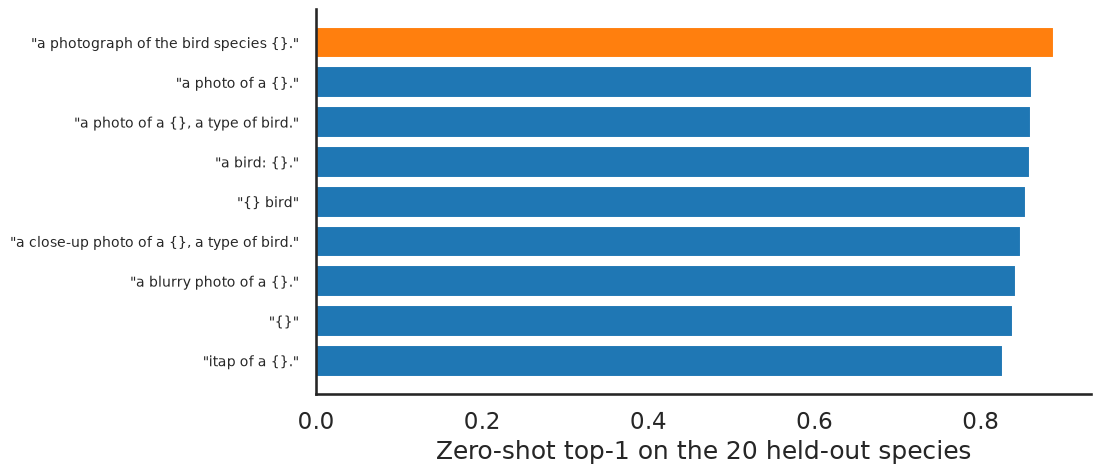

In [34]:
fig, ax = plt.subplots(figsize=(10, 5))
order = sorted(prompt_scores, key=lambda template: prompt_scores[template]['top-1'])
ax.barh(np.arange(len(order)), [prompt_scores[t]['top-1'] for t in order],
        color=['tab:orange' if t == BEST_TEMPLATE else 'tab:blue' for t in order])
ax.set(yticks=np.arange(len(order)), yticklabels=['"{}"'.format(t) for t in order],
       xlabel='Zero-shot top-1 on the 20 held-out species')
ax.tick_params(axis='y', labelsize=10)
sns.despine()

Now, and only now, the 100 unseen species — with the template chosen above, and with the canonical
`"a photo of a {}, a type of bird."` alongside it, since that is what most people reach for without
measuring.

In [35]:
CANONICAL = 'a photo of a {}, a type of bird.'
for label, template in (('selected on held-out species', BEST_TEMPLATE), ('canonical', CANONICAL)):
    scores = zero_shot(template, open_species, open_idx, y_open_local)
    print('{:30s} "{}"'.format(label, template))
    print('{:30s} top-1 {:6.2%}  top-5 {:6.2%}'.format('', scores['top-1'], scores['top-5']))
print('\nchance over 100 species is {:.2%}'.format(1 / 100))

selected on held-out species   "a photograph of the bird species {}."
                               top-1 51.06%  top-5 80.06%


canonical                      "a photo of a {}, a type of bird."
                               top-1 51.11%  top-5 80.23%

chance over 100 species is 1.00%


Six points of spread on the held-out species, and the winner is worth **nothing** on the unseen ones —
it lands on top of the template we would have used without measuring at all.

That deserves a post-mortem rather than a shrug. The choice is already made and cannot be unmade by
looking, so scoring all nine templates on the unseen species now costs us nothing and tells us why.

In [36]:
prompt_comparison = pd.DataFrame({
    'held-out (20 species)': {t: s['top-1'] for t, s in prompt_scores.items()},
    'unseen (100 species)': {t: zero_shot(t, open_species, open_idx, y_open_local)['top-1']
                             for t in TEMPLATES},
})
prompt_comparison['rank on 20'] = prompt_comparison['held-out (20 species)'].rank(ascending=False)
prompt_comparison['rank on 100'] = prompt_comparison['unseen (100 species)'].rank(ascending=False)
prompt_comparison = prompt_comparison.sort_values('rank on 20')
print(prompt_comparison.to_string(formatters={
    'held-out (20 species)': '{:.2%}'.format, 'unseen (100 species)': '{:.2%}'.format,
    'rank on 20': '{:.0f}'.format, 'rank on 100': '{:.0f}'.format}))

rho = prompt_comparison['rank on 20'].corr(prompt_comparison['rank on 100'], method='spearman')
print('\nSpearman correlation between the two rankings: {:+.2f}'.format(rho))

                                          held-out (20 species) unseen (100 species) rank on 20 rank on 100
a photograph of the bird species {}.                     88.84%               51.06%          1           5
a photo of a {}.                                         86.16%               50.93%          2           6
a photo of a {}, a type of bird.                         86.07%               51.11%          3           4
a bird: {}.                                              85.91%               53.31%          4           1
{} bird                                                  85.49%               52.55%          5           3
a close-up photo of a {}, a type of bird.                84.82%               50.00%          6           9
a blurry photo of a {}.                                  84.23%               50.54%          7           8
{}                                                       83.89%               52.77%          8           2
itap of a {}.               

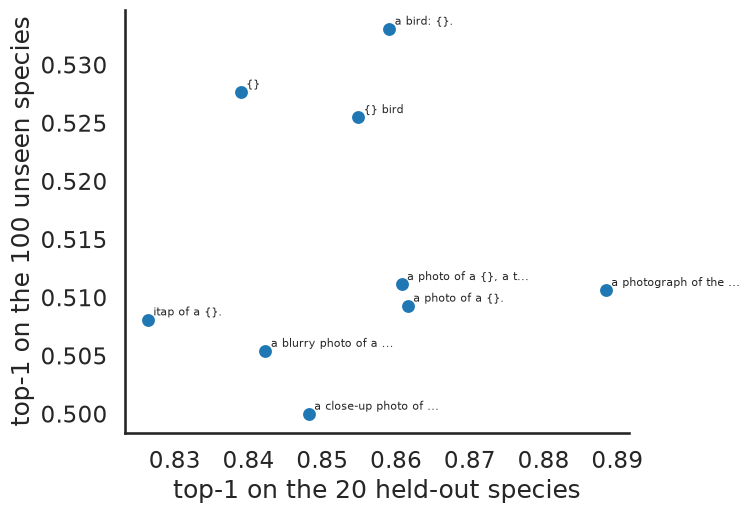

In [37]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(prompt_comparison['held-out (20 species)'], prompt_comparison['unseen (100 species)'],
           s=60, color='tab:blue')
for template, row in prompt_comparison.iterrows():
    ax.annotate(template if len(template) < 22 else template[:20] + '...',
                (row['held-out (20 species)'], row['unseen (100 species)']),
                fontsize=8, xytext=(4, 3), textcoords='offset points')
ax.set(xlabel='top-1 on the 20 held-out species', ylabel='top-1 on the 100 unseen species')
sns.despine()

The two rankings are barely related. A template can be best of nine on twenty species and middling on a
hundred, and the ordering reshuffles almost completely.

The reason is arithmetic, not linguistics. The held-out set is 1,192 images over a **20**-way choice;
the unseen set is 5,924 over a **100**-way choice. They are different problems with different confusion
structures, and the smaller one is noisy enough that a six-point spread across nine templates is mostly
sampling noise dressed up as an effect. We chose carefully and correctly, and we still gained nothing —
which is the honest outcome, and a more useful thing to have watched happen than a tidy win.

This is the margin all over again. Both times an effect looked real on the 20 held-out species, and both
times it failed to reproduce on 100 different ones. Twenty classes is simply not a big enough selection
set to resolve differences of a few points, and that is a statement about our protocol, not about
margins or prompts.

None of it says prompt engineering never works. CLIP's own paper measures a substantial gain from prompt
ensembling averaged over ImageNet, where class names such as *crane* and *bolt* genuinely need
disambiguating. CUB's class names are already unambiguous bird species, so there is nothing for a
template to disambiguate here — and that is exactly the kind of thing you find out by measuring rather
than by importing someone else's prompt.

## CLIP's image encoder is also a metric space

Zero-shot classification used CLIP's text side. Its image side is an embedding like any other, and we
can score it with exactly the same `retrieval_scores` we used on the models we trained — same images,
same 100 species, same metrics. No text, no prompts, no labels, no fitting.

In [38]:
clip_scores = retrieval_scores(Z_clip[open_idx], y_open)

comparison = pd.DataFrame({
    'Frozen ImageNet features': frozen_scores,
    'Softmax cross-entropy': softmax_scores,
    cosine_name: cosine_scores,
    'CLIP ViT-B/16 image encoder': clip_scores,
}).T
print(comparison.to_string(formatters={column: '{:.2%}'.format for column in comparison}))

                               R@1    R@5   R@10  mAP@R
Frozen ImageNet features    48.92% 75.83% 84.99% 12.24%
Softmax cross-entropy       52.28% 79.32% 87.56% 15.61%
Cosine head (s=8)           52.73% 78.65% 86.90% 16.36%
CLIP ViT-B/16 image encoder 62.68% 88.13% 93.82% 20.21%


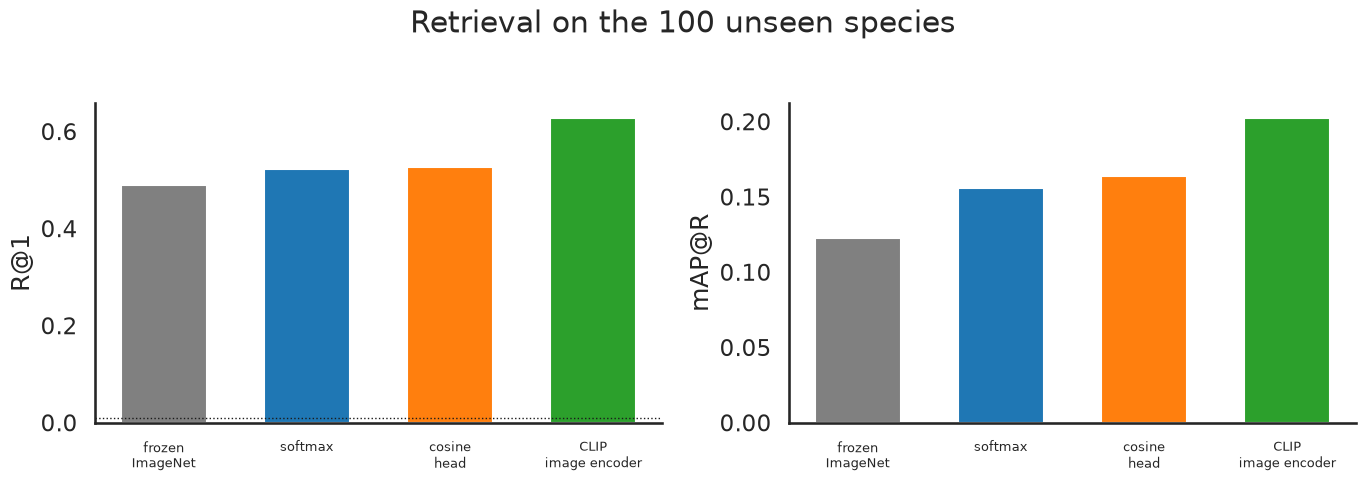

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
colors = ['gray', 'tab:blue', 'tab:orange', 'tab:green']
ticklabels = ['frozen\nImageNet', 'softmax', 'cosine\nhead', 'CLIP\nimage encoder']
for ax, metric in zip(axes, ('R@1', 'mAP@R')):
    ax.bar(np.arange(len(comparison)), comparison[metric], color=colors, width=0.6)
    ax.set(xticks=np.arange(len(comparison)), ylabel=metric)
    ax.set_xticklabels(ticklabels, fontsize=9)
axes[0].axhline(1 / 100, ls=':', c='k', lw=1)
fig.suptitle('Retrieval on the 100 unseen species', y=1.02)
sns.despine()
fig.tight_layout()

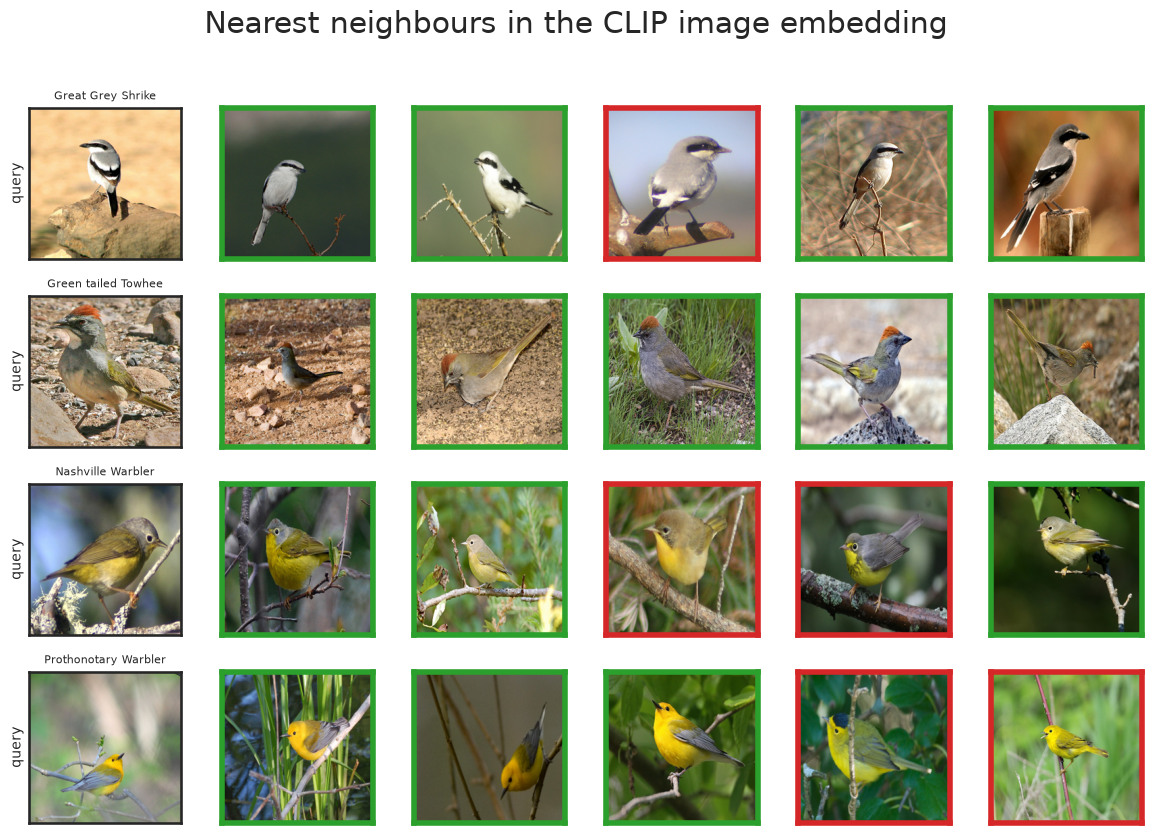

In [40]:
plot_neighbours(Z_clip[open_idx], y_open, open_idx, rng.choice(len(open_idx), size=4, replace=False),
                title='Nearest neighbours in the CLIP image embedding')

**The model that was never trained on a bird wins.** CLIP's image encoder, used with no labels, no
metric learning and no fitting of any kind, is a better space for retrieving unseen bird species than
anything we trained on top of EfficientNetV2S.

**One caveat, and it matters more now that CLIP is winning outright.** CUB-200-2011 is a public dataset
from 2011 and its images are all over the web. We have no way to know they were not in CLIP's 400-million-
image training set, and "zero-shot" here means only that CLIP never saw *our* labels — not that it never
saw these photographs. That applies to the retrieval row as much as to the prompt experiments. Treat
every CLIP number in this notebook as an upper bound.

## Closing the loop: the same three heads, on CLIP features

`Z_clip` is already computed, and everything above is a function of a feature matrix. So the obvious
question costs one more sweep: **is the margin worthless, or was it only worthless on that backbone?**

If the margin buys nothing here either, we have a much sharper claim than "the backbone dominates" — we
have evidence about ArcFace itself. If it does buy something, then the null result on EfficientNetV2S was
partly a story about how much there was left to gain.

Same protocol throughout, and re-run rather than carried over: the same grid, the same selection on the
same 20 held-out species, the same per-configuration epoch budgets.

In [41]:
t0 = time.time()
clip_curves = sweep_scale(Z_clip)
clip_sweep = summarize_sweep(clip_curves)
print('{} scales in {:.0f}s\n'.format(len(clip_curves), time.time() - t0))
print('mAP@R on the 20 held-out species, CLIP features')
print(clip_sweep.to_string(
    formatters={c: '{:.2%}'.format for c in clip_sweep.columns if c != 'best epoch'}))

6 scales in 24s

mAP@R on the 20 held-out species, CLIP features
     at epoch 20   best  best epoch
s                                  
2.0       69.30% 70.48%          11
4.0       71.38% 71.72%          14
8.0       71.39% 71.63%          15
16.0      69.34% 69.57%          15
32.0      66.60% 66.60%          20
64.0      63.24% 63.40%          25


In [42]:
CLIP_SCALE = clip_sweep['best'].idxmax()
print('\nbest scale on CLIP features: s = {:.0f}  (on EfficientNetV2S it was s = {:.0f})'.format(
    CLIP_SCALE, BEST_SCALE))

clip_heads = {
    'Softmax cross-entropy': lambda seed, n, d, lr: build_softmax(seed, n, d, lr),
    'Cosine head (s={:.0f})'.format(CLIP_SCALE):
        lambda seed, n, d, lr: build_cosine(seed, n, d, lr, CLIP_SCALE),
}

clip_runs = {}
for name, builder in clip_heads.items():
    clip_runs[name] = []
    for seed in SEEDS:
        model, _, epochs = fit_final(builder, name, features=Z_clip, seed=seed, quiet=True)
        clip_runs[name].append(retrieval_scores(
            encoder_of(model).predict(Z_clip[open_idx], batch_size=512, verbose=0), y_open))

print('\non the 100 unseen species, CLIP features, {} seeds'.format(len(SEEDS)))
print('{:30s}'.format('frozen CLIP, no training')
      + '  '.join('{} {:6.2%}'.format(k, v) for k, v in clip_scores.items()))
for name, scores in clip_runs.items():
    print('{:30s}'.format(name) + '  '.join(
        '{} {:.2%}-{:.2%}'.format(k, min(s[k] for s in scores), max(s[k] for s in scores))
        for k in scores[0]))


best scale on CLIP features: s = 4  (on EfficientNetV2S it was s = 8)



on the 100 unseen species, CLIP features, 3 seeds
frozen CLIP, no training      R@1 62.68%  R@5 88.13%  R@10 93.82%  mAP@R 20.21%
Softmax cross-entropy         R@1 68.65%-69.31%  R@5 90.09%-90.34%  R@10 94.67%-94.87%  mAP@R 29.49%-29.72%
Cosine head (s=4)             R@1 69.83%-70.59%  R@5 89.84%-90.12%  R@10 94.06%-94.23%  mAP@R 31.86%-31.97%


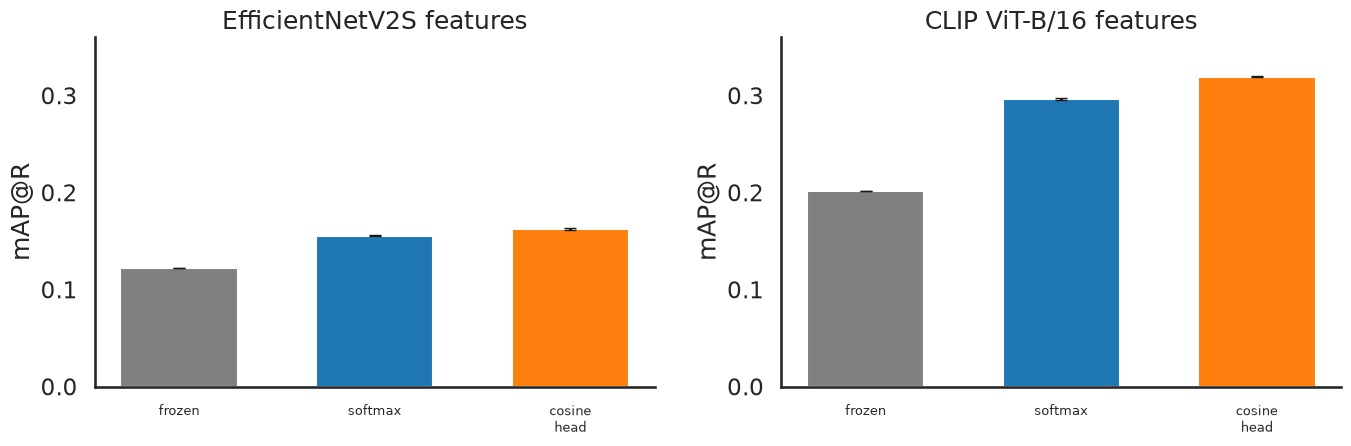

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=False)
labels_ = ['frozen', 'softmax', 'cosine\nhead']
for ax, (title, frozen, trained) in zip(axes, (
        ('EfficientNetV2S features', frozen_scores, runs),
        ('CLIP ViT-B/16 features', clip_scores, clip_runs))):
    values = [frozen['mAP@R']] + [np.mean([s['mAP@R'] for s in v]) for v in trained.values()]
    errors = [[0] + [np.mean([s['mAP@R'] for s in v]) - min(s['mAP@R'] for s in v)
                     for v in trained.values()],
              [0] + [max(s['mAP@R'] for s in v) - np.mean([s['mAP@R'] for s in v])
                     for v in trained.values()]]
    n = len(values)
    ax.bar(np.arange(n), values,
           color=['gray', 'tab:blue', 'tab:orange', 'tab:orange', 'tab:red'][:n], width=0.6)
    ax.errorbar(np.arange(n), values, yerr=errors, fmt='none', ecolor='k', capsize=4)
    ax.set(xticks=np.arange(n), ylabel='mAP@R', title=title, ylim=(0, 0.36))
    ax.set_xticklabels(labels_[:len(values)], fontsize=9)
sns.despine()
fig.tight_layout()

**Training on CLIP features is worth four times what it was worth on EfficientNetV2S.** The same two
heads, the same protocol, the same 100 unseen species: on EfficientNetV2S the whole distance from no
training to the best head is about four points of mAP@R, and on CLIP features it is twelve. The cosine
head's advantage over plain softmax grows with it — from under a point to over two, non-overlapping
seed ranges in both cases.

That is the answer to the question this section asked, and it is not the one about CLIP. **A method's
measured benefit is a property of the experiment as much as of the method.** The normalized head is the
same layer in both halves, doing the same thing; what changed is how much room there was for it to
matter. On a backbone with four points of headroom, a method worth a fraction of a point is
indistinguishable from a method worth nothing, and no amount of care about seeds or protocols will
separate them — the only fix is more headroom.

Hold on to that, because it is the reason this notebook stops where it does. The angular margin that
completes ArcFace is worth *less* than the normalization, which means on EfficientNetV2S it is
unmeasurable in principle, not merely unmeasured. Chasing it here would be chasing a signal smaller than
the floor. [`sessions/reid.ipynb`](reid.ipynb) picks it up where the floor is lower and the problem —
hundreds of individuals, one to ten photographs each — is the one it was designed for.

# Discussion

**Normalizing the proxies works, and the scale is not plumbing.** Replacing the final `Dense` layer with
a normalized, rescaled one improves open-set retrieval by more than the seed-to-seed spread on both
backbones. Nearly all of the tuning that matters is the scale $s$: two points of mAP@R across the grid,
more than the head itself buys over plain softmax, from a parameter introduced to stop the cross-entropy
bottoming out. The paper values of 30 and 64 are both on the wrong side of the curve for this problem,
and an earlier draft of this notebook reported "best $s = 16$" from a grid whose smallest value was 16 —
a boundary, not an optimum.

**Almost everything else here is about the protocol rather than the method.** Three corrections were
needed to get the numbers above, and each one changed a conclusion:

- an epoch budget chosen once, on one model, and shared across a comparison — which measures the budget;
- a sweep whose grid stopped at the value it then selected — which measures the grid;
- hyperparameters chosen on the species we report, rather than on species held out for the purpose.

None of the three looks like a mistake while you are making it. All three produce a clean-looking table.

**Does any of this change when the backbone can move?** It is a fair objection that frozen features give
a head nothing to reshape. `scripts/metric_learning_finetune.py` answers it with the recipe
[`transfer.ipynb`](transfer.ipynb) arrives at, including **LP-FT** ([Kumar et al. 2022](https://arxiv.org/abs/2202.10054)):
warm the head up on the cached features first — they are already computed — then unfreeze `block6*` and
`top_*` with batch-norm frozen and a warmup-then-cosine schedule. The scale and the epoch budget are
re-selected in that regime rather than carried over, on species 81–100 held out from a fit on 1–80:

| backbone | head | epochs | R@1 | mAP@R |
|---|---|---|---|---|
| frozen | softmax | 25 | 52.3% | 15.6% |
| frozen | cosine head | 11 | 52.7% | 16.4% |
| LP-FT | softmax | 7 | 60.9% | 21.7% |
| LP-FT | cosine head | 6 | **61.1%** | **22.5%** |

**Letting the backbone move is worth about eight points of `R@1` and six of mAP@R** — several times what
the choice of head is worth, and the same lesson the CLIP comparison delivers by a different road. The
ordering of the heads does not change. Each fine-tune row is a single seed, which is the caveat on them.

**Zero-shot is not free, it is just not trained.** CLIP picks the right species out of 100 about half
the time given nothing but a list of English names, which is remarkable for a model that was shown no
labels. (Resist comparing that number to the `R@1` column: a 100-way choice among text proxies and a
ranking of a 5,923-image gallery are different tasks.) Fine-grained taxonomy is near the limit of what
web captions can teach: a caption says "a bird", rarely "a Henslow's Sparrow".
[BioCLIP](https://arxiv.org/abs/2311.18803) (Stevens et al. 2024) is the direct response — the same
architecture trained on TreeOfLife-10M with taxonomic labels, and much better at exactly this. It has no
KerasHub preset, so we are not running it here.

**And the backbone dominates everything on this page.** Untrained CLIP features already beat the
best-trained EfficientNetV2S embedding, and trained CLIP features beat it by a factor of two on mAP@R.
Every decision in the first half — the loss, the scale, the budget — was being made inside a box whose
size had been fixed before any of them. A study comparing losses on one fixed backbone can be entirely
correct and still be measuring the smaller effect.

Hold that conclusion at arm's length, though, because the contamination caveat is load-bearing for it
rather than decorative. We are claiming that CLIP's pretraining data is what wins, and CUB's images
plausibly *are* part of that pretraining data. Strictly the two readings are the same reading —
contamination is pretraining data, and "it has seen more of the internet" does not stop being true when
the internet included these photographs. But it changes how far the claim travels: on a dataset
genuinely absent from CLIP's training set the gap would be smaller, and we cannot say by how much.
Exercise 6 is the experiment that would begin to separate them.

**What the two halves have in common.** `CosineHead` holds a matrix of proxies and scores an image by
its angle to each column. CLIP's text encoder produces a matrix of proxies and scores an image by its
angle to each column. One is fitted to photographs, the other is written in English. That is the whole
difference, and it is why the same four lines of arithmetic score both.

# Exercises

1. **Does the embedding dimension matter?** `EMBEDDING_DIM` is 512 because that is the conventional
   choice. Sweep it over 64, 128, 256, 512 and 1024 on the held-out species, with the same per-run
   stopping rule. [Musgrave et al. 2020](https://arxiv.org/abs/2003.08505) found the embedding dimension
   to be worth more than most of the loss functions they compared — is it worth more than the scale is
   here?

2. **Recall@K versus mAP@R.** Find a query among the unseen species where the two metrics disagree
   sharply — `R@1` of 1 with a low `AP@R` — and plot its ten nearest neighbours with `plot_neighbours`.
   What kind of mistake does `R@1` hide?

3. **Add the angular margin, and try to measure it.** This is the piece the notebook deliberately
   stopped short of. Replace the plain cross-entropy with a custom loss that applies
   $\cos(\theta_y + m) = \cos\theta_y\cos m - \sin\theta_y\sin m$ to the true class only — the margin
   needs the labels, so it belongs in the loss, not in `CosineHead`. Two traps are waiting:

   - $\sin\theta = \sqrt{1 - \cos^2\theta}$ is finite at $\cos\theta = \pm 1$ but its **derivative** is
     not, and $\cos\theta = 1$ is what a perfectly fitted sample looks like. Clip $\cos\theta$ to
     $[-1+\varepsilon, 1-\varepsilon]$ *inside* the `sqrt`. Check the gradient of your loss at a
     saturated logit before you train anything: an infinite gradient on the true class becomes a `NaN`
     on every other class, because `ops.where` multiplies the unselected branch by zero.
   - $\cos(\theta + m)$ stops being monotone in $\theta$ once $\theta + m > \pi$, so gradient descent
     gets rewarded for making things worse. The reference implementation falls back to
     $\cos\theta - m\sin(\pi - m)$ there.

   Then sweep $m$ jointly with $s$ — they interact, so a one-dimensional sweep of either will mislead —
   choosing both on the held-out species. **Write down what you expect first.** Our answer is in the
   discussion above, and it is about the size of the effect relative to the size of the experiment.

4. **Prompt ensembling.** The notebook picks a single best template. CLIP's paper instead *averages* the
   text embeddings of many templates and reports a gain from doing so. Implement it — encode all nine,
   average, re-normalize — selecting on the held-out species as usual. Does ensembling beat the single
   best template here, and can you say why it does or does not?

5. **Where is CLIP wrong?** Build the 100 x 100 confusion matrix of the zero-shot classifier and find the
   species it confuses. Are they visually similar birds, or birds with confusable English names? The two
   failure modes have different fixes, and only one of them is a vision problem.

The last two are larger — a session's work each rather than a cell — and they are the two experiments
this notebook most obviously leaves undone.

6. **Separate "more data" from "language supervision".** The discussion claims CLIP's lead comes from its
   pretraining data rather than its capacity, but the comparison is confounded: CLIP differs from
   EfficientNetV2S in architecture, data scale *and* training objective at once. KerasHub ships
   `vit_base_patch16_224_imagenet21k` — the **same architecture, resolution and patch size as
   CLIP ViT-B/16**, trained on ImageNet-21k's 14 million images with 21,000 supervised labels instead of
   400 million image–caption pairs. Run the frozen-feature comparison a third time on it, with the same
   sweep and the same two heads.

   That gives three points on a line: 1.3M images with 1,000 labels (EfficientNetV2S), 14M with 21,000
   (ViT-21k), 400M with free-text captions (CLIP), with architecture held fixed across the last two. How
   much of CLIP's 14-point `R@1` lead is scale, and how much is language? Note that `keras.applications`
   has no 21k weights for any model, so this one has to come from KerasHub — and that KerasHub's own
   `EfficientNetBackbone` presets are all ImageNet-1k, so the clean control really does have to be the
   ViT.

7. **Fine-tune CLIP's vision encoder.** CLIP wins twice here without ever being adapted to birds. What
   happens when the good backbone is also allowed to move? `CLIPVisionEncoder` is an ordinary Keras
   model whose top-level layers are `clip_vision_encoder_embedding`, a pre-layer-norm, twelve named
   `clip_vision_encoder_encoder_block_0…11` and a final layer norm, so you can unfreeze the last few by
   name exactly as `transfer.ipynb` unfreezes `block6*`. Build the embedding as
   `vision_projection(vision_pooler(vision_encoder({'images': ...})))`. Three things differ from the
   EfficientNetV2 fine-tune and all three matter:
   - a ViT has **no `BatchNormalization`** — LayerNorm keeps no running statistics — so the single most
     important rule of that session has nothing to act on here;
   - `vision_projection` does *not* L2-normalize its output, while the cached features every head in
     this notebook was trained on are normalized, so add a `UnitNormalization` layer if you want the two
     paths to be comparable;
   - 86 million pretrained parameters against 5,864 images is the feature-distortion regime of
     [Kumar et al. 2022](https://arxiv.org/abs/2202.10054) at its worst, so warm the head up on the
     cached features first and use a learning rate around `1e-5`.

   Keep the protocol: choose the scale and the epoch budget on species 81–100, refit on all 100, report
   once. A worked solution is in
   [`solutions/metric_learning_clip_finetune.py`](../solutions/metric_learning_clip_finetune.py) — try it
   yourself first, because the prediction is the part that teaches.

# References

- Song, Xiang, Jegelka & Savarese 2016, [Deep Metric Learning via Lifted Structured Feature Embedding](https://arxiv.org/abs/1511.06452), CVPR - the source of the train-on-the-first-100-classes protocol.
- Schroff, Kalenichenko & Philbin 2015, [FaceNet: A Unified Embedding for Face Recognition and Clustering](https://arxiv.org/abs/1503.03832), CVPR - the triplet loss and semi-hard mining.
- Movshovitz-Attias, Toshev, Leung, Ioffe & Singh 2017, [No Fuss Distance Metric Learning using Proxies](https://arxiv.org/abs/1703.07464), ICCV - where proxy-based losses come from.
- Deng, Guo, Xue & Zafeiriou 2019, [ArcFace: Additive Angular Margin Loss for Deep Face Recognition](https://arxiv.org/abs/1801.07698), CVPR.
- Deng, Guo, Liu, Gong & Zafeiriou 2020, [Sub-center ArcFace: Boosting Face Recognition by Large-scale Noisy Web Faces](https://arxiv.org/abs/2007.12137), ECCV - Exercise 2.
- Musgrave, Belongie & Lim 2020, [A Metric Learning Reality Check](https://arxiv.org/abs/2003.08505), ECCV - the fair-comparison study, and the source of mAP@R.
- Radford et al. 2021, [Learning Transferable Visual Models From Natural Language Supervision](https://arxiv.org/abs/2103.00020), ICML - CLIP.
- Stevens et al. 2024, [BioCLIP: A Vision Foundation Model for the Tree of Life](https://arxiv.org/abs/2311.18803), CVPR.
- Luo, Gu, Liao, Lai & Jiang 2019, [Bag of Tricks and A Strong Baseline for Deep Person Re-identification](https://arxiv.org/abs/1903.07071), CVPR Workshops - the source of the BNNeck trunk.
- Wah, Branson, Welinder, Perona & Belongie 2011, [The Caltech-UCSD Birds-200-2011 Dataset](https://www.vision.caltech.edu/datasets/cub_200_2011/), CNS-TR-2011-001.
- [KerasHub CLIP API](https://keras.io/keras_hub/api/models/clip/) and the [pretrained presets](https://keras.io/keras_hub/presets/).
- [Keras functional API and Siamese networks](functional_keras.ipynb) - the pair-based treatment this session builds on.
- [Transfer learning](transfer.ipynb) - the closed-set treatment of the same dataset and the same backbone.
- [`solutions/metric_learning_clip_finetune.py`](../solutions/metric_learning_clip_finetune.py) - a worked solution to Exercise 7, fine-tuning CLIP's vision encoder on CUB.

# Colophon
This notebook was written by [Yoav Ram](http://python.yoavram.com).

This work is licensed under a CC BY-NC-SA 4.0 International License.

![Python logo](https://www.python.org/static/community_logos/python-logo.png)